## Исследование объявлений о продаже квартир

### Изучение содержания датасета

In [1]:
%pip install pandas -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install matplotlib -qq
%pip install seaborn -qqq

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import sys
print(sys.executable)

C:\Users\User\Documents\Практикум_проекты_DA_почищенные\da_jupyter_venv\Scripts\python.exe


In [5]:
df = pd.read_csv('real_estate_data.сsv', sep='\t')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  str    
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  str    
 15  airports_nearest      18157 no

Изучение содержания датасета:
* *first_day_exposition* - дата в формате "object", нужно будет преобразовать в тип "дата".
* *ceiling_height* - высота потолков указна не для всех объявлений - количество пропусков значительно, по моим ожиданиям высота потолков в среднем от двух с половиной до трех, можно заполнить пропуски средними или медианными значениями.
* *floors_total* - у нескольких квартир не заполнено количество этажей, возможно это одноэтажный дом, чтобы проверить, надо посмотреть на показатель floor, если floor = 1, то пропущенные значения можно заменить на единицы для красоты. Пропусков мало, поэтому на итоговые средние и медианные значения они сильно влиять не будут. В целом можно заполнить нулями, медианными значениями.
* *living_area* - не заполнена жилая площадь. На вскидку около 10% объявлений, что довольно много. Можно ориентироваться на показатель "total_area" и заполнить среней долей жилой площали от обзей площади из выборки, где заполнен показатель "living_area"
* *is_apartment* - Почему-то тип не bool, как у следующего поля с похожим содержанием. Возможно есть дургие значения, кроме True/False.
* *kitchen_area* - пропущено значительно количество данных. Можно проанализировать объевления с пропущенной площадью кухни, вдруг тут есть связь с тем, что это студия или апартаменты. Если связь есть и площадь кухни пропущена в апартаментах/студиях, то можно заменить пропуски на фиксированные значения - 6 м кв. Если связи нет, то заменить на медианное значение площади кухни. upd. Гипотеза про апартаменты и студии не подтвердилась - в первых десяти строках видно, что пропус случайный. Заменяем на медианные значения, т.к. зачастую площадь кухни в самых распространенных квартирах не зависит от количества комнат, общей площади.
* *balcony* - тип данных float64 - возможны ошибки, ожидаем что у балконов тип должен быть int. Дробного количества балконов быть не должно. Проверяем уникальные значения. Возможно пропуски соответствуют отсутствию балкона, тогда все пропущенные значения заменяем на 0.
* *locality_name* - количество пропусков незначительное, оставляем как есть (можно и удалить).
* airports_nearest/cityCenters_nearest - заполнить средним значением для аналогичных "locality_name"
* parks_around3000/ponds_around3000 - заполнить средним значением для аналогичных "locality_name"
* parks_nearest/ponds_nearest - заполнить средним значением для аналогичных "locality_name"
* *days_exposition* - пропуски можно считать еще активными объявлениями. Если считать, что датасет снят на сегодня, то пропуски можно заполнить количеством дней от "first_day_exposition" до сегодняшнего дня (проблема в том, что датасет похоже довольно старый, если заполнить таким образом даты до 2023 года, то может получиться массив очень больших чисел, применение анализа по среднему значению будет неточным).


In [6]:
pd.options.display.max_columns = None # отображение всех колонок датасета, по умолчанию скрывает studio и open_plan
# pd.options.display.max_rows = None
df.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


array([[<Axes: title={'center': 'total_images'}>,
        <Axes: title={'center': 'last_price'}>,
        <Axes: title={'center': 'total_area'}>,
        <Axes: title={'center': 'rooms'}>],
       [<Axes: title={'center': 'ceiling_height'}>,
        <Axes: title={'center': 'floors_total'}>,
        <Axes: title={'center': 'living_area'}>,
        <Axes: title={'center': 'floor'}>],
       [<Axes: title={'center': 'kitchen_area'}>,
        <Axes: title={'center': 'balcony'}>,
        <Axes: title={'center': 'airports_nearest'}>,
        <Axes: title={'center': 'cityCenters_nearest'}>],
       [<Axes: title={'center': 'parks_around3000'}>,
        <Axes: title={'center': 'parks_nearest'}>,
        <Axes: title={'center': 'ponds_around3000'}>,
        <Axes: title={'center': 'ponds_nearest'}>],
       [<Axes: title={'center': 'days_exposition'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

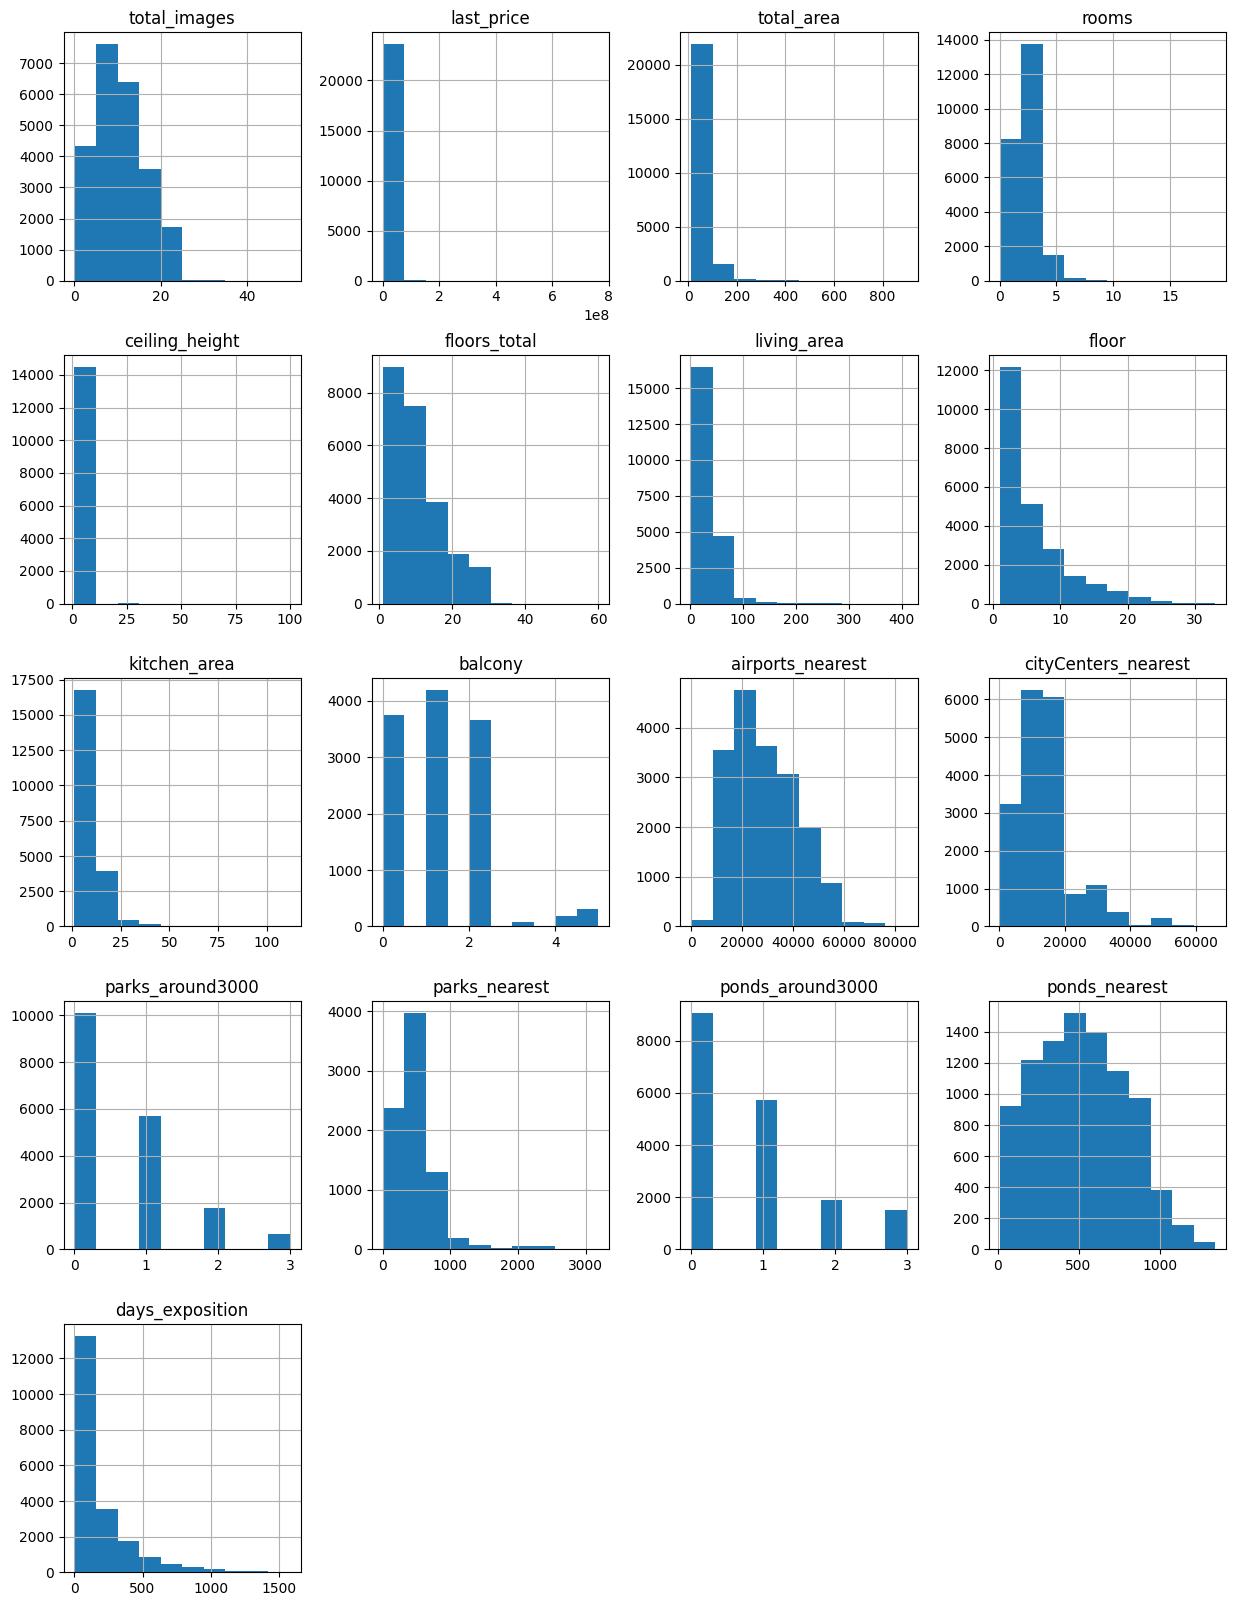

In [7]:
df.hist(figsize=(15, 20))

нельзя построить гистограмму для first_day_exposition
нельзя построить гистограмму для is_apartment
нельзя построить гистограмму для studio
нельзя построить гистограмму для open_plan
нельзя построить гистограмму для locality_name


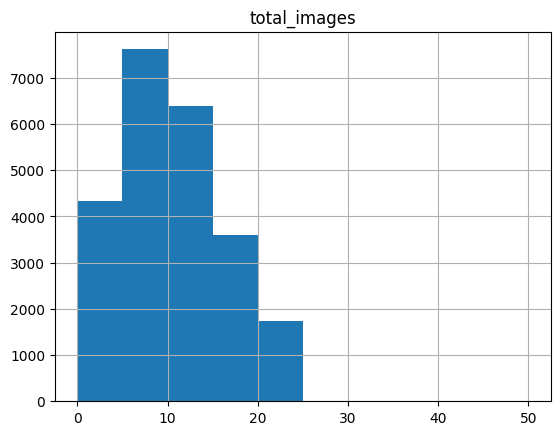

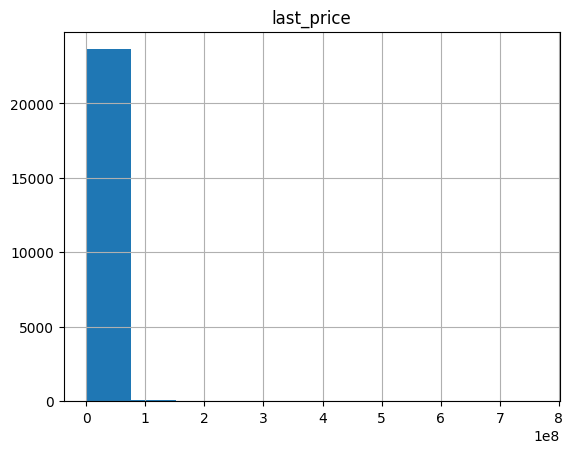

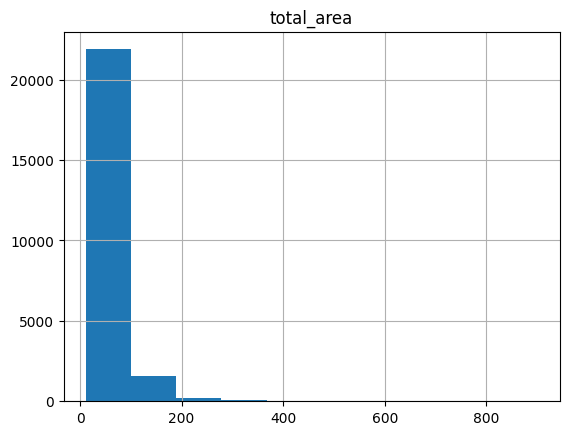

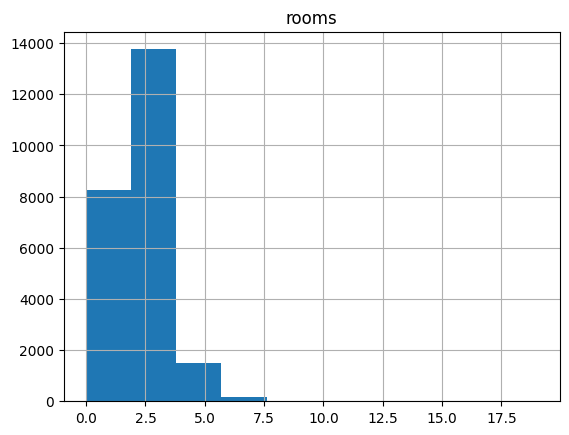

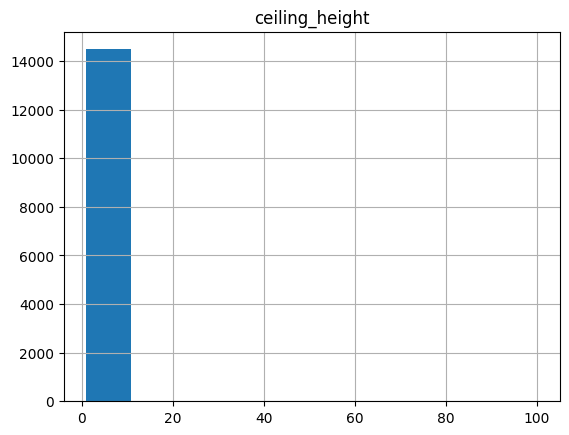

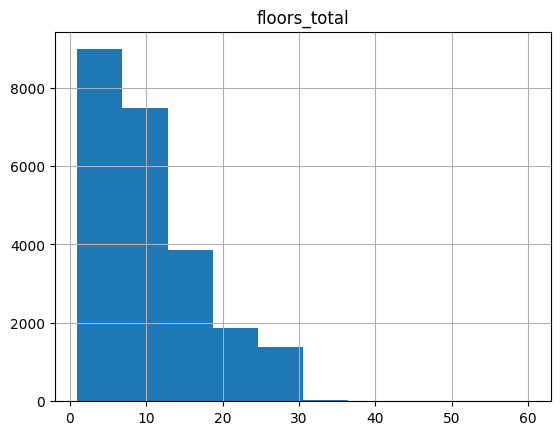

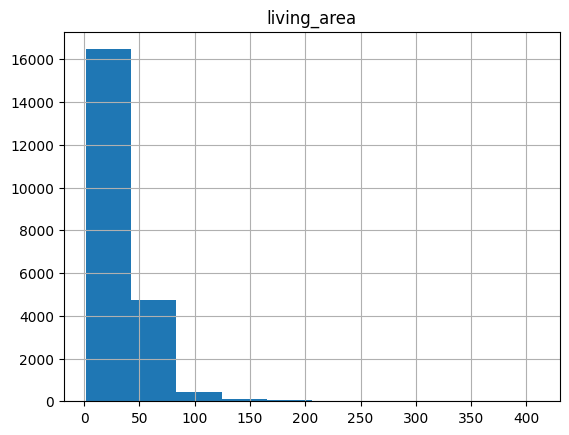

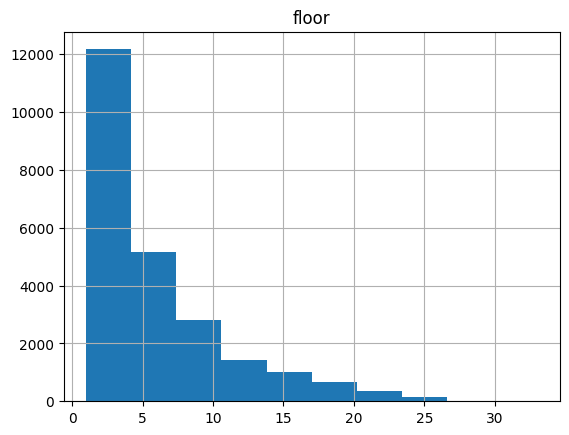

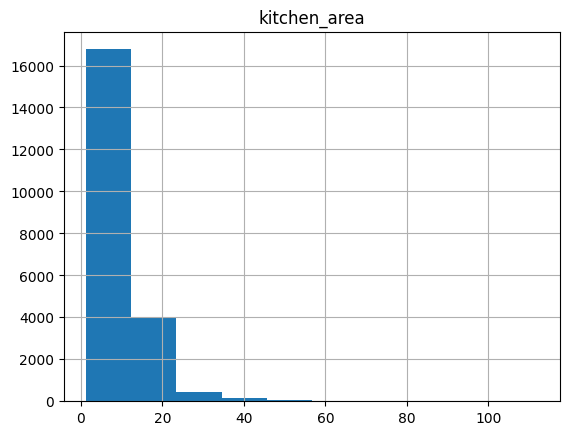

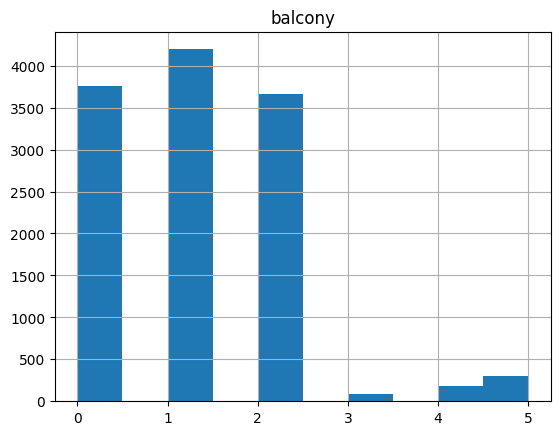

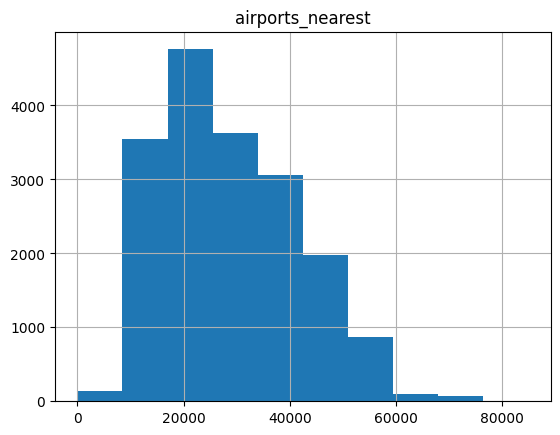

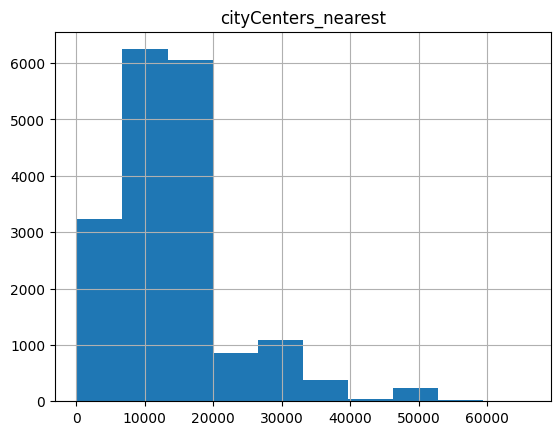

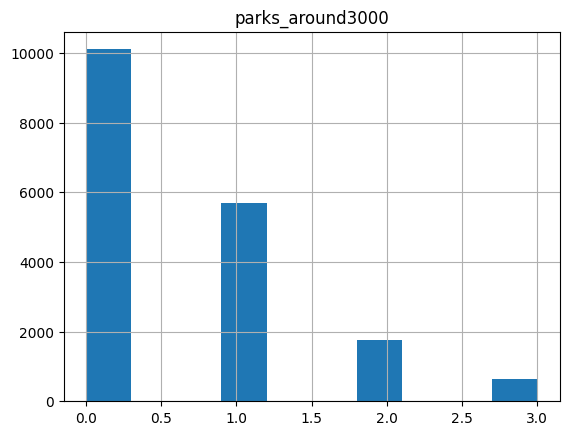

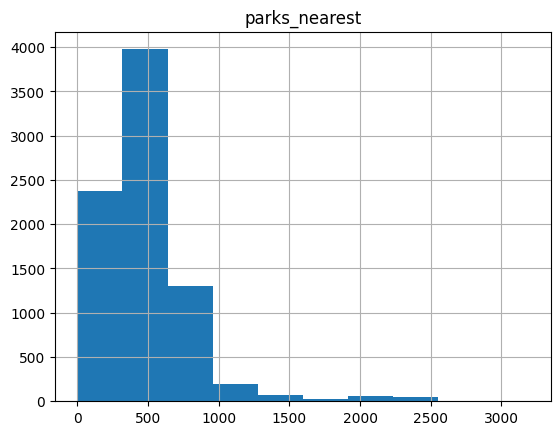

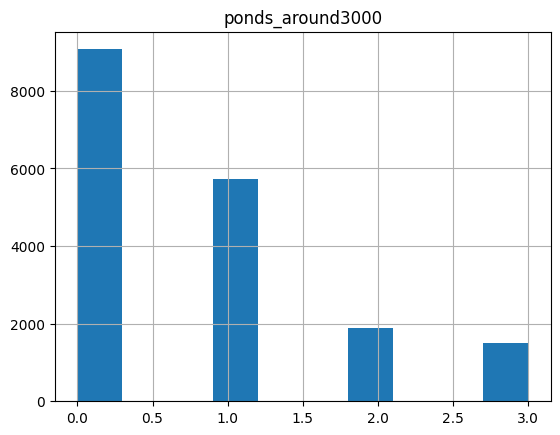

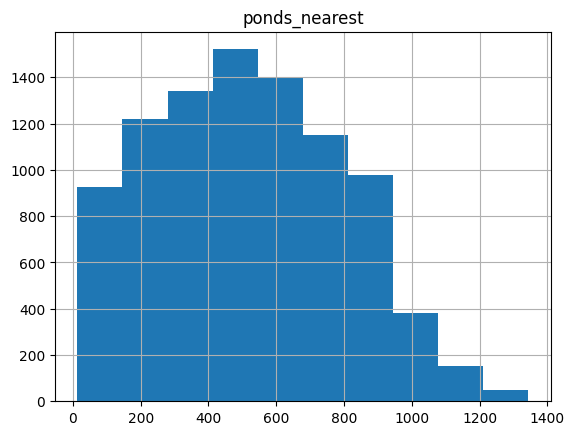

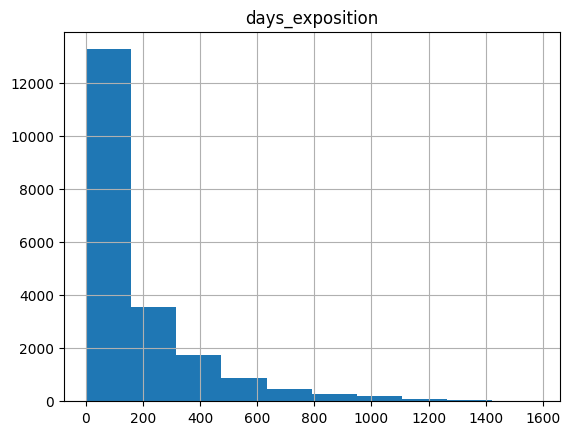

In [8]:
# for data in df.columns:
#     if df[data].dtypes not in ['object','bool']:
#         df.hist(data)
#     else: 
#         print('нельзя построить гистограмму для', data)
        
# Такой вариант работает также
for data in df.columns:
    try:
        df.hist(data)
    except:
        print('нельзя построить гистограмму для', data)

### Предобработка данных

#### Работа с пропусками

##### first_day_exposition - Не получилось задать формат с часами-минутами-секундами

In [9]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'])
df.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


##### floors_total

In [10]:
df[df['floors_total'].isna()].head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
186,12,11640000.0,65.2,2018-10-02,2,NaN,NaN,30.80,4,NaN,False,False,12.00,NaN,Санкт-Петербург,39197.0,12373.0,1.0,123.0,0.0,NaN,49.0
237,4,2438033.0,28.1,2016-11-23,1,NaN,NaN,20.75,1,NaN,False,False,NaN,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,251.0
457,4,9788348.0,70.8,2015-08-01,2,NaN,NaN,38.40,12,NaN,False,False,10.63,0.0,Санкт-Петербург,37364.0,8322.0,2.0,309.0,2.0,706.0,727.0
671,4,6051191.0,93.6,2017-04-06,3,NaN,NaN,47.10,8,NaN,False,False,16.80,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,123.0
1757,5,3600000.0,39.0,2017-04-22,1,NaN,NaN,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,22735.0,11618.0,1.0,835.0,1.0,652.0,77.0


Предположение, что этажность не указана в одноэтажных домах не оправдалась, обычные пропуски. Можно заполнить значениями из поля с этажом квартиры (скорее всего люди скрывают последний или первый этаж).

In [11]:
for row in df[df['floors_total'].isna() == True].index:
    df.loc[row, 'floors_total'] = df.loc[row, 'floor']

In [12]:
df.loc[186,:] #проверка, что floors_total = floor

total_images                             12
last_price                       11640000.0
total_area                             65.2
first_day_exposition    2018-10-02 00:00:00
rooms                                     2
ceiling_height                          NaN
floors_total                            4.0
living_area                            30.8
floor                                     4
is_apartment                            NaN
studio                                False
open_plan                             False
kitchen_area                           12.0
balcony                                 NaN
locality_name               Санкт-Петербург
airports_nearest                    39197.0
cityCenters_nearest                 12373.0
parks_around3000                        1.0
parks_nearest                         123.0
ponds_around3000                        0.0
ponds_nearest                           NaN
days_exposition                        49.0
Name: 186, dtype: object

##### ceiling_height

* Интернет говорит, что квартиры с высотой потолков 10м впоне могут быть.
* Квартир с высотой потолков от 20 до 100 метров быть не может. Допускаю что ошиблись с указанием десятичной части. Значение высоты потолков в таких квартирах делим на 10.
* посмотрели на квартиры с высотой потолком меньше 2-х метров. Добавили 1м, считаем, что имеет место опечатка.
* Заполняем пустые значения медианными

In [13]:
df['ceiling_height'] = df['ceiling_height'].apply(lambda x: x/10 if x>20 else x)
df['ceiling_height'] = df['ceiling_height'].apply(lambda x: x+1 if x<2 else x)
df['ceiling_height'].unique()

array([ 2.7 ,   nan,  3.03,  2.5 ,  2.67,  2.56,  3.05,  2.75,  2.6 ,
        2.9 ,  2.8 ,  2.55,  3.  ,  2.65,  3.2 ,  2.61,  3.25,  3.45,
        2.77,  2.85,  2.64,  2.57,  4.15,  3.5 ,  3.3 ,  2.71,  4.  ,
        2.47,  2.73,  2.84,  3.1 ,  2.34,  3.4 ,  3.06,  2.72,  2.54,
        2.51,  2.78,  2.76,  2.58,  3.7 ,  2.52,  5.2 ,  2.87,  2.66,
        2.59,  2.  ,  2.45,  3.6 ,  2.92,  3.11,  3.13,  3.8 ,  3.15,
        3.55,  3.16,  3.62,  3.12,  2.53,  2.74,  2.96,  2.46,  5.3 ,
        5.  ,  2.79,  2.95,  4.06,  2.94,  3.82,  3.54,  3.53,  2.83,
        4.7 ,  2.4 ,  3.38,  3.01,  5.6 ,  3.65,  3.9 ,  3.18,  3.35,
        2.3 ,  3.57,  2.48,  2.62,  2.82,  3.98,  2.63,  3.83,  3.52,
        3.95,  3.75,  2.88,  3.67,  3.87,  3.66,  3.85,  3.86,  4.19,
        3.24,  4.8 ,  4.5 ,  4.2 ,  3.36,  3.08,  3.68,  3.07,  3.37,
        3.09,  8.  ,  3.26,  3.34,  2.81,  3.44,  2.97,  3.14,  4.37,
        2.68,  3.22,  3.27,  4.1 ,  2.93,  3.46,  3.47,  3.33,  3.63,
        3.32,  2.2 ,

In [14]:
df['ceiling_height'] = df['ceiling_height'].fillna(df['ceiling_height'].median())

##### living_area

* Закономерности в пропущенных значениях не наблюдается.
* Есть предложение посчитать средний процент, который составляет жилая площадь от полной площади и заполнить пустные значения умножив "total_area" на рассчитанный процент.

In [15]:
living_area_filled = df[~df['living_area'].isna()]
living_area_share = living_area_filled['living_area'].sum() / living_area_filled['total_area'].sum()
living_area_share

np.float64(0.5734446218294134)

In [16]:
df['living_area'] = df['living_area'].fillna(df['total_area'] * living_area_share)

##### is_apartment

In [17]:
df['is_apartment'].unique()

array([nan, False, True], dtype=object)

Кроме ожидаемых значений False, True есть значения NaN. Заполняем пропуски значениями False - считаем, что если человек оставил поле незаполненным, значит к его квартире этот параметр не относится - считаем, что его квартира не апартаменты.

In [18]:
df['is_apartment'] = df['is_apartment'].fillna(False)
df['is_apartment'].unique()

array([False, True], dtype=object)

##### kitchen_area

In [19]:
df.groupby('rooms')['kitchen_area'].agg({'count','median'})

,count,median
rooms,,
0,0,NaN
1,7213,9.04
2,7286,8.80
3,5380,9.50
4,1081,11.10
5,285,15.10
6,97,19.50
7,52,20.00
8,9,25.00


Медианные значения площадей кухонь у основного количества квартир очень близкое 8.80-11.10 м кв. При принятии решения о приобретении квартиры погрешность в площади кухни в 2м кв. не будеи иметь решающего значения, если мы заполним все пропуски медианным значением (среднее значение также подойдет)

In [20]:
df['kitchen_area'] = df['kitchen_area'].fillna(df['kitchen_area'].median())
df.groupby('rooms')['kitchen_area'].agg({'count','median'})

,count,median
rooms,,
0,197,9.10
1,8047,9.10
2,7940,9.00
3,5814,9.10
4,1180,10.50
5,326,14.40
6,105,18.70
7,59,18.00
8,12,23.10


##### balcony 

In [21]:
df['balcony'].unique()

array([nan,  2.,  0.,  1.,  5.,  4.,  3.])

Заполняем пустые зачения нулями, считаем, что раз автор объявления не указал балконы, значит их нет.

In [22]:
df['balcony'] = df['balcony'].fillna(0)
df['balcony'].unique()

array([0., 2., 1., 5., 4., 3.])

##### locality_name

In [23]:
df[df['locality_name'].isna()]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1097,3,8600000.0,81.70,2016-04-15,3,3.55,5.0,50.800000,2,False,False,False,8.80,0.0,NaN,23478.0,4258.0,0.0,NaN,0.0,NaN,147.0
2033,6,5398000.0,80.00,2017-05-30,3,2.65,4.0,42.600000,2,False,False,False,18.60,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0
2603,20,3351765.0,42.70,2015-09-20,1,2.65,24.0,15.600000,3,False,False,False,10.70,0.0,NaN,22041.0,17369.0,0.0,NaN,1.0,374.0,276.0
2632,2,5130593.0,62.40,2015-10-11,2,2.65,24.0,33.100000,21,False,False,False,8.20,0.0,NaN,22041.0,17369.0,0.0,NaN,1.0,374.0,256.0
3574,10,4200000.0,46.50,2016-05-28,2,2.65,5.0,30.800000,5,False,False,False,6.50,0.0,NaN,27419.0,8127.0,0.0,NaN,1.0,603.0,45.0
4151,17,17600000.0,89.50,2014-12-09,2,3.00,8.0,39.620000,7,False,False,False,13.38,0.0,NaN,25054.0,3902.0,1.0,485.0,3.0,722.0,869.0
4189,7,9200000.0,80.00,2015-12-10,3,4.00,4.0,52.300000,3,False,False,False,10.40,0.0,NaN,21774.0,3039.0,1.0,690.0,1.0,953.0,223.0
4670,1,5500000.0,83.00,2015-08-14,3,2.65,7.0,47.595904,6,False,False,False,9.10,0.0,NaN,26534.0,5382.0,1.0,446.0,1.0,376.0,350.0
5343,19,13540000.0,85.50,2016-01-20,3,2.65,7.0,59.100000,5,False,False,False,8.30,4.0,NaN,10556.0,9538.0,1.0,67.0,0.0,NaN,303.0
5707,7,3700000.0,30.00,2016-04-29,1,2.65,24.0,20.000000,23,False,False,False,9.10,0.0,NaN,21460.0,16788.0,0.0,NaN,1.0,170.0,49.0


Так как расположение квартиры имеет ключевое значение при покупки, для принятия решения о покупке, картиры с незаполненным полем "locality_name" не нужны. Пропуски удаляем.

In [24]:
df.dropna(subset=['locality_name'], inplace=True)

##### airports_nearest

In [25]:
df.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.000000,8,False,False,False,25.0,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.600000,1,False,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.300000,4,False,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,2.65,14.0,91.177695,9,False,False,False,9.1,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.000000,13,False,False,False,41.0,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [26]:

df.groupby('locality_name')['cityCenters_nearest'].count().head(20)

locality_name
Бокситогорск       0
Волосово           0
Волхов             0
Всеволожск         0
Выборг             0
Высоцк             0
Гатчина            0
Зеленогорск       24
Ивангород          0
Каменногорск       0
Кингисепп          0
Кириши             0
Кировск            0
Колпино          337
Коммунар           0
Красное Село     176
Кронштадт         95
Кудрово            0
Лодейное Поле      0
Ломоносов        132
Name: cityCenters_nearest, dtype: int64

Очень странно, что картографические данные полностью не заполнены для множества малых населенных пунктов. Данные отсутствуюn для сел, поселков и т.д. не вижу причины не указать информацию о расстоянии до основного аэропорта региона. Вопрос к логике составления датасета. Т.к. в некоторых ячейках картографических данных присутствуют нули, предлагаю заменить NaN на нули.

In [27]:
df['airports_nearest'] = df['airports_nearest'].replace(np.nan, 0)
df['cityCenters_nearest'] = df['cityCenters_nearest'].replace(np.nan, 0)
df['parks_around3000'] = df['parks_around3000'].replace(np.nan, 0)
df['parks_nearest'] = df['parks_nearest'].replace(np.nan, 0)
df['ponds_around3000'] = df['ponds_around3000'].replace(np.nan, 0)
df['ponds_nearest'] = df['ponds_nearest'].replace(np.nan, 0)

df.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.000000,8,False,False,False,25.0,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.600000,1,False,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.300000,4,False,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,2.65,14.0,91.177695,9,False,False,False,9.1,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.000000,13,False,False,False,41.0,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


##### days_exposition

In [28]:
df[df['days_exposition'].isna()].head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.000000,8,False,False,False,25.0,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
7,5,7915000.0,71.6,2019-04-18,2,2.65,24.0,41.058635,22,False,False,False,18.9,2.0,Санкт-Петербург,23982.0,11634.0,0.0,0.0,0.0,0.0,NaN
44,13,5350000.0,40.0,2018-11-18,1,2.65,22.0,22.937785,3,False,False,False,9.1,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN
45,17,5200000.0,50.6,2018-12-02,2,2.65,9.0,30.300000,7,False,False,False,7.0,0.0,Санкт-Петербург,30011.0,12872.0,0.0,0.0,0.0,0.0,NaN
46,17,6600000.0,52.1,2019-01-31,2,2.60,24.0,29.700000,9,False,False,False,8.3,2.0,Санкт-Петербург,15114.0,12702.0,0.0,0.0,0.0,0.0,NaN


Какой-то логики в незаполненных ячейках не вижу. Можно сделать вывод, что это еще активные объявления, т.к. незаполнено поле в относительно новых объявлениях.

#### Проверка датасета

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 23650 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23650 non-null  int64         
 1   last_price            23650 non-null  float64       
 2   total_area            23650 non-null  float64       
 3   first_day_exposition  23650 non-null  datetime64[us]
 4   rooms                 23650 non-null  int64         
 5   ceiling_height        23650 non-null  float64       
 6   floors_total          23650 non-null  float64       
 7   living_area           23650 non-null  float64       
 8   floor                 23650 non-null  int64         
 9   is_apartment          23650 non-null  object        
 10  studio                23650 non-null  bool          
 11  open_plan             23650 non-null  bool          
 12  kitchen_area          23650 non-null  float64       
 13  balcony               23650 non-

#### Проверка неявных дубликатов в названиях населённых пунктов

* Меняем 'ё' на е'
* Ради интереса приведем все названия к нижнему регистру и проверим изменится ли количество уникальных записей

In [30]:
df['locality_name'].unique().shape

(364,)

In [31]:
df['locality_name'] = df['locality_name'].str.replace('ё', 'е')
df['locality_name'].unique().shape

(330,)

In [32]:
df['locality_name'] = df['locality_name'].str.lower()
len(df['locality_name'].unique())

330

#### Изучение аномалий в столбцах

##### Стоимость квартиры

<Axes: >

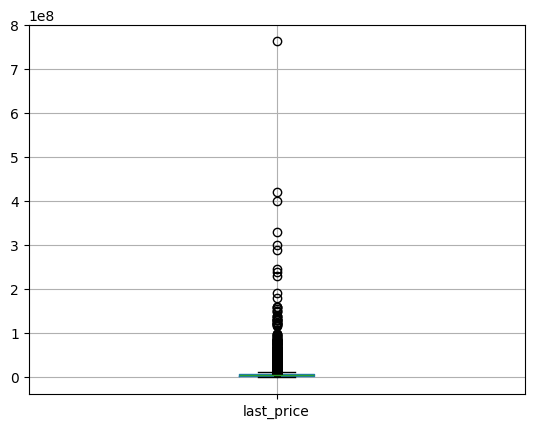

In [33]:
df.boxplot(column='last_price')

В выбросы попало всё, что более где-то 20млн руб. Отфильтруем наш датафрейм по этой границе, изучим содержание

In [34]:
df[df['last_price'] > 20000000].shape[0] / df.shape[0]

0.02985200845665962

3% значений, можно удалить.

In [35]:
df[df['last_price'] > 100000000].sort_values(by='last_price').head(100)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
21923,10,115490000.0,235.0,2017-04-09,5,4.90,5.0,140.000000,5,False,False,False,50.00,0.0,санкт-петербург,22777.0,1328.0,3.0,652.0,3.0,253.0,351.0
1188,20,118000000.0,290.6,2018-06-01,6,3.82,6.0,188.700000,3,False,False,False,22.00,1.0,санкт-петербург,25309.0,6224.0,1.0,217.0,0.0,0.0,316.0
20264,17,119000000.0,187.6,2017-07-10,4,6.00,7.0,147.000000,7,False,False,False,15.60,0.0,санкт-петербург,26902.0,5605.0,3.0,484.0,1.0,305.0,259.0
1300,14,120000000.0,280.0,2018-07-12,5,4.70,4.0,162.000000,3,False,False,False,30.00,0.0,санкт-петербург,24680.0,4247.0,1.0,464.0,3.0,339.0,225.0
16647,15,122000000.0,145.0,2017-04-25,3,3.30,6.0,36.000000,2,False,False,False,72.00,0.0,санкт-петербург,33931.0,7023.0,2.0,478.0,3.0,250.0,335.0
4996,20,124000000.0,124.5,2017-10-12,4,3.00,4.0,67.200000,2,False,False,False,20.00,0.0,санкт-петербург,20399.0,1722.0,3.0,302.0,3.0,172.0,45.0
21023,17,124350000.0,248.7,2015-08-27,4,3.40,9.0,131.000000,4,False,False,False,23.00,0.0,санкт-петербург,21946.0,2242.0,1.0,679.0,1.0,227.0,501.0
20349,17,124480000.0,267.7,2016-06-18,4,2.65,8.0,107.030000,8,False,False,False,29.86,0.0,санкт-петербург,27102.0,7442.0,2.0,164.0,2.0,473.0,205.0
1928,11,125000000.0,224.5,2017-01-24,4,2.65,4.0,163.500000,3,False,False,False,30.00,1.0,санкт-петербург,22805.0,2335.0,0.0,0.0,2.0,497.0,174.0
21955,19,130000000.0,431.0,2017-10-02,7,3.70,8.0,220.000000,5,False,False,False,20.00,5.0,санкт-петербург,0.0,0.0,0.0,0.0,0.0,0.0,161.0


Не вижу, чтобы в отобранном массиве были подозрительные/ошибочные объявления. С точки зрения статистики это выбросы, которые доставляют сложность при анализе гистаграмм и графиков. На деле - обычные объявления о продаже из раздела "элитное жилье": огромные площади, близко к центру, разнообразные планеровки по компантам и жилым площадям.

In [36]:
df.drop(df[df['last_price'] > 20000000].index, inplace=True)

##### Общая площадь

<Axes: >

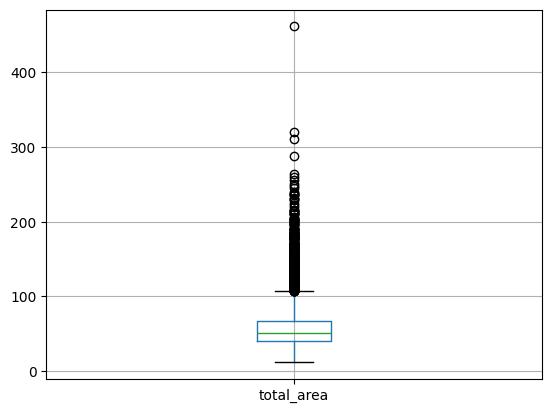

In [37]:
df.boxplot(column='total_area')

Посмотрим на все общие площади больше 200м кв.

In [38]:
df[df['total_area'] > 200].sort_values(by='total_area', ascending=False).head(50)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
20273,12,20000000.0,460.80,2019-03-20,6,3.10,3.0,279.600000,1,False,False,False,55.50,0.0,санкт-петербург,43756.0,15459.0,1.0,852.0,3.0,122.0,21.0
11087,3,14000000.0,320.00,2017-09-27,6,2.65,3.0,190.000000,3,False,False,False,28.00,0.0,красное село,26020.0,29445.0,1.0,569.0,0.0,0.0,8.0
13397,14,19500000.0,309.70,2016-02-03,9,2.65,5.0,199.000000,5,False,False,False,14.30,0.0,санкт-петербург,10328.0,9987.0,2.0,352.0,0.0,0.0,468.0
22238,12,19500000.0,287.50,2017-12-27,7,2.65,4.0,183.700000,3,False,False,False,26.00,0.0,санкт-петербург,21881.0,4726.0,1.0,578.0,1.0,853.0,90.0
9397,10,16073000.0,263.80,2019-01-30,3,2.65,19.0,151.274691,4,False,False,False,23.42,0.0,санкт-петербург,18805.0,4400.0,0.0,0.0,0.0,0.0,35.0
12067,5,14500000.0,259.60,2015-09-28,5,2.81,17.0,148.600000,16,False,False,False,15.40,0.0,санкт-петербург,39408.0,11111.0,0.0,0.0,0.0,0.0,1232.0
2489,9,12500000.0,255.00,2017-04-21,3,2.65,2.0,153.900000,2,False,False,False,100.70,0.0,санкт-петербург,29544.0,6916.0,0.0,0.0,3.0,198.0,102.0
13931,13,14300000.0,250.00,2018-04-04,5,2.50,17.0,119.000000,16,False,False,False,21.00,0.0,санкт-петербург,39441.0,11144.0,0.0,0.0,0.0,0.0,222.0
7729,20,16000000.0,248.00,2017-07-25,7,3.32,6.0,166.700000,2,False,False,False,25.30,0.0,санкт-петербург,20074.0,3147.0,2.0,575.0,3.0,56.0,9.0
20788,7,18000000.0,245.00,2017-04-06,8,3.54,5.0,155.000000,2,False,False,False,9.10,0.0,санкт-петербург,22215.0,2424.0,1.0,867.0,1.0,340.0,357.0


In [39]:
df[df['total_area'] > 200].shape[0] / df.shape[0]

0.0018305439330543933

Доля таких объявлений меньше 1%, можно удалить. Подозрений по поводу адекватности данных почти нет, разве что в некоторых объявлениях проседает стоимость квадратного метра, есть ряд объявлений с большой площадью и сравнительно низкой стоимостью, тут хорошо бы посмотреть вживую на примеры таких квартир, вдруг ошиблись на порядок и занизили стоимость в 10 раз.

In [40]:
df.drop(df[df['total_area'] > 200].index, inplace=True)

##### Количество комнат

<Axes: >

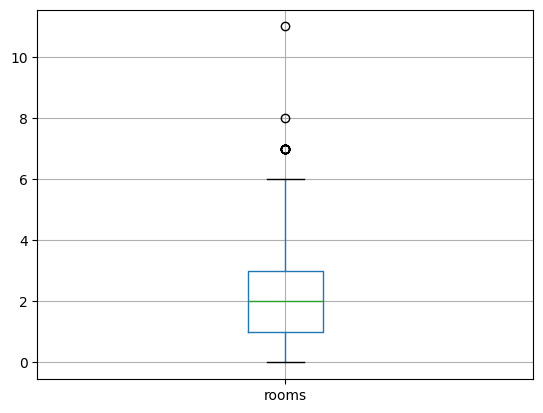

In [41]:
df.boxplot(column='rooms')

In [42]:
df[df['rooms'] > 7].shape[0] / df.shape[0]

8.732861758798358e-05

Квартир с количеством комнат больше 7 всего 0,13%. Если удалить на общий вывод не сильно повлияет.

In [43]:
df[df['rooms'] > 7].sort_values(by='rooms', ascending=False).head(50)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
648,3,17500000.0,183.7,2018-07-01,11,3.40,7.0,138.8,7,False,False,False,13.3,0.0,санкт-петербург,23606.0,3148.0,0.0,0.0,0.0,0.0,NaN
8758,5,16100000.0,150.0,2018-07-10,8,2.92,5.0,107.0,1,False,False,False,7.2,0.0,санкт-петербург,26080.0,4782.0,2.0,473.0,0.0,0.0,NaN


Судя по цене, первые пять объявления похожи на продажу общежитий целиком. Можно удалить по желанию.

In [44]:
df.drop(df[df['rooms'] > 7].index, inplace=True)

### Посчитайте и добавьте в таблицу новые столбцы

In [45]:
df.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,False,False,25.0,0.0,санкт-петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.6,1,False,False,False,11.0,2.0,поселок шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.3,4,False,False,False,8.3,0.0,санкт-петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,False,False,41.0,0.0,санкт-петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.4,2018-09-10,1,2.65,12.0,14.4,5,False,False,False,9.1,0.0,городской поселок янино-1,0.0,0.0,0.0,0.0,0.0,0.0,55.0


#### Цена одного квадратного метра

In [46]:
df['sqmeter_price'] = df['last_price'] / df['total_area']

#### День публикации объявления

In [47]:
df['first_exposition_day'] = df['first_day_exposition'].dt.day % 7
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sqmeter_price,first_exposition_day
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,False,False,25.0,0.0,санкт-петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370.370370,0
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.6,1,False,False,False,11.0,2.0,поселок шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0,82920.792079,4
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.3,4,False,False,False,8.3,0.0,санкт-петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92785.714286,6
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,False,False,41.0,0.0,санкт-петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,100000.000000,5
5,10,2890000.0,30.4,2018-09-10,1,2.65,12.0,14.4,5,False,False,False,9.1,0.0,городской поселок янино-1,0.0,0.0,0.0,0.0,0.0,0.0,55.0,95065.789474,3


In [48]:
days_of_week = {
    '0':'понедельник',
    '1':'вторник',
    '2':'среда',
    '3':'четверг',
    '4':'пятница',
    '5':'суббота',
    '6':'воскресение',
    }
df['first_exposition_day'] = df['first_exposition_day'].astype(str)
df['first_exposition_day'] = df['first_exposition_day'].map(days_of_week)
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sqmeter_price,first_exposition_day
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,False,False,25.0,0.0,санкт-петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370.370370,понедельник
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.6,1,False,False,False,11.0,2.0,поселок шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0,82920.792079,пятница
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.3,4,False,False,False,8.3,0.0,санкт-петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92785.714286,воскресение
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,False,False,41.0,0.0,санкт-петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,100000.000000,суббота
5,10,2890000.0,30.4,2018-09-10,1,2.65,12.0,14.4,5,False,False,False,9.1,0.0,городской поселок янино-1,0.0,0.0,0.0,0.0,0.0,0.0,55.0,95065.789474,четверг


#### Месяц публикации объявления

In [49]:
df['first_exposition_month'] = df['first_day_exposition'].dt.month

#### Год публикации объявления

In [50]:
df['first_exposition_year'] = df['first_day_exposition'].dt.year

#### Тип этажа квартиры

In [51]:

def floor_type(data_frame):
    if data_frame['floor'] == 1:
        return 'первый'
    elif data_frame['floor'] == data_frame['floors_total']:
        return 'последний'
    else:
        return 'другой'
        
df['floor_type'] = df.apply(floor_type, axis=1)

In [52]:
df.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sqmeter_price,first_exposition_day,first_exposition_month,first_exposition_year,floor_type
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,False,False,25.0,0.0,санкт-петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370.370370,понедельник,3,2019,другой
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.6,1,False,False,False,11.0,2.0,поселок шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0,82920.792079,пятница,12,2018,первый
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.3,4,False,False,False,8.3,0.0,санкт-петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92785.714286,воскресение,8,2015,другой
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,False,False,41.0,0.0,санкт-петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,100000.000000,суббота,6,2018,другой
5,10,2890000.0,30.4,2018-09-10,1,2.65,12.0,14.4,5,False,False,False,9.1,0.0,городской поселок янино-1,0.0,0.0,0.0,0.0,0.0,0.0,55.0,95065.789474,четверг,9,2018,другой


#### Расстояние в км до центра города

In [53]:
df['cityCenters_nearest'] = df['cityCenters_nearest'].fillna(0)

In [54]:
df['cityCenters_nearest'] = df['cityCenters_nearest'] / 1000
df['cityCenters_nearest'] = df['cityCenters_nearest'].astype(int)

In [55]:
df.head(100)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sqmeter_price,first_exposition_day,first_exposition_month,first_exposition_year,floor_type
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,False,False,25.0,0.0,санкт-петербург,18863.0,16,1.0,482.0,2.0,755.0,NaN,120370.370370,понедельник,3,2019,другой
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.6,1,False,False,False,11.0,2.0,поселок шушары,12817.0,18,0.0,0.0,0.0,0.0,81.0,82920.792079,пятница,12,2018,первый
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.3,4,False,False,False,8.3,0.0,санкт-петербург,21741.0,13,1.0,90.0,2.0,574.0,558.0,92785.714286,воскресение,8,2015,другой
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,False,False,41.0,0.0,санкт-петербург,31856.0,8,2.0,112.0,1.0,48.0,121.0,100000.000000,суббота,6,2018,другой
5,10,2890000.0,30.4,2018-09-10,1,2.65,12.0,14.4,5,False,False,False,9.1,0.0,городской поселок янино-1,0.0,0,0.0,0.0,0.0,0.0,55.0,95065.789474,четверг,9,2018,другой
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,11,11700000.0,80.0,2014-12-10,3,2.65,5.0,55.1,3,False,False,False,11.0,0.0,санкт-петербург,11248.0,8,1.0,666.0,0.0,0.0,831.0,146250.000000,четверг,12,2014,другой
99,32,9600000.0,90.0,2017-09-26,4,2.65,5.0,67.0,2,False,False,False,8.0,0.0,санкт-петербург,23277.0,2,0.0,0.0,0.0,0.0,104.0,106666.666667,суббота,9,2017,другой
100,16,3800000.0,38.6,2018-02-22,1,2.65,9.0,18.0,6,False,False,False,8.4,2.0,санкт-петербург,36450.0,13,0.0,0.0,0.0,0.0,8.0,98445.595855,вторник,2,2018,другой
101,4,3000000.0,37.0,2019-03-23,1,2.75,10.0,12.0,3,False,False,False,13.0,0.0,садовое товарищество новая ропша,0.0,0,0.0,0.0,0.0,0.0,NaN,81081.081081,среда,3,2019,другой


### Проведите исследовательский анализ данных

#### общая площадь

In [56]:
df['total_area'].median()

np.float64(51.0)

In [57]:
df['total_area'].mean()

np.float64(56.37384672489083)

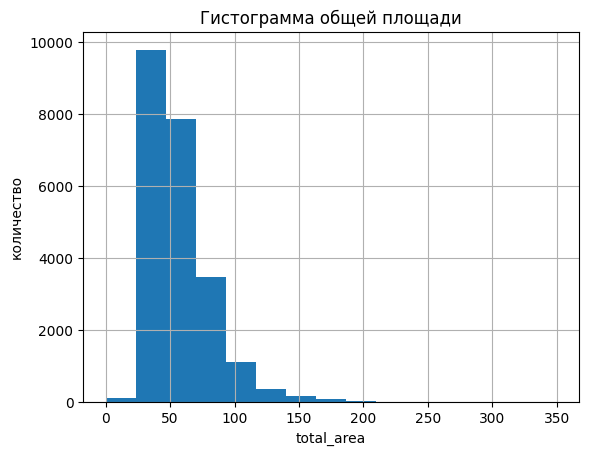

In [58]:
# df['total_area'].hist(bins=15, range=(0,350))
fig, ax = plt.subplots()
ax.hist(df['total_area'], bins=15, range=(0,350))
ax.set_xlabel('total_area')
ax.set_ylabel('количество')
ax.set_title('Гистограмма общей площади')
ax.grid()

Вывод: 
* Больше всего объявлений на рынке недвижимости площадью от 25м кв. до 75м кв.
* Медианное значение - 52.0
* Среднее значени - 60.33

#### жилая площаль

In [59]:
df['living_area'].median()

np.float64(30.0)

In [60]:
df['living_area'].mean()

np.float64(32.340362544012564)

Text(0.5, 1.0, 'living_area')

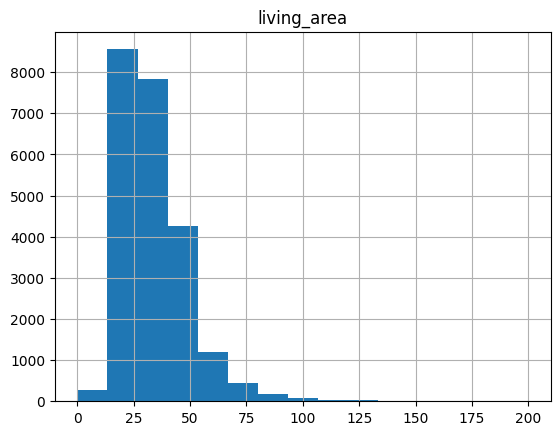

In [61]:
df['living_area'].hist(bins=15, range=(0, 200))
plt.title('living_area')

Вывод: 
* Больше всего объявлений на рынке недвижимости с жилой площадью от 15 кв. до 50м кв.
* Медианное значение - 30.0
* Среднее значени - 34.59

#### площадь кухни

In [62]:
df['kitchen_area'].median()

np.float64(9.1)

In [63]:
df['kitchen_area'].mean()

np.float64(9.995870305676856)

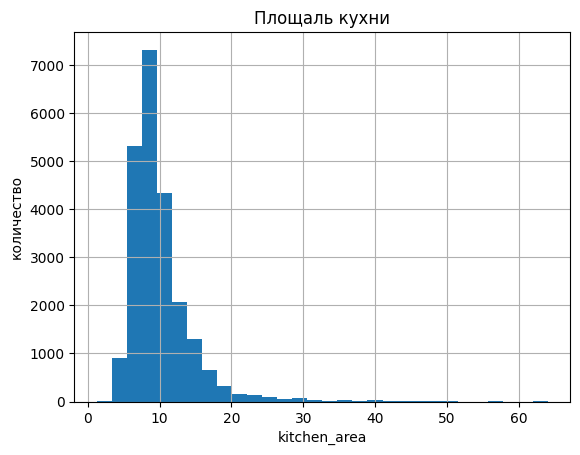

In [64]:
# df['kitchen_area'].hist(bins=30)
fig, ax = plt.subplots()
ax.hist(df['kitchen_area'], bins=30)
ax.set_xlabel('kitchen_area')
ax.set_ylabel('количество')
ax.set_title('Площаль кухни')
ax.grid()

Вывод: 
* Больше всего объявлений на рынке недвижимости с площадью кухни от 5кв. до 10м кв.
* Медианное значение - 9.1
* Среднее значени - 10.42

#### цена объекта

In [65]:
df['last_price'].median()

np.float64(4550000.0)

In [66]:
df['last_price'].mean()

np.float64(5400699.183668123)

Text(0.5, 1.0, 'last_price')

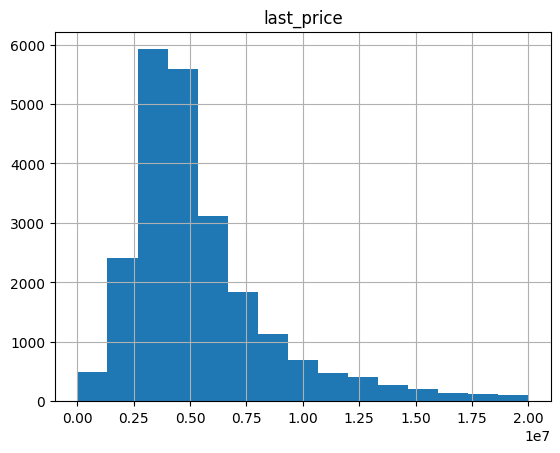

In [67]:
df['last_price'].hist(bins=15, range=(0, 20000000))
plt.title('last_price')

Text(0.5, 1.0, 'last_price')

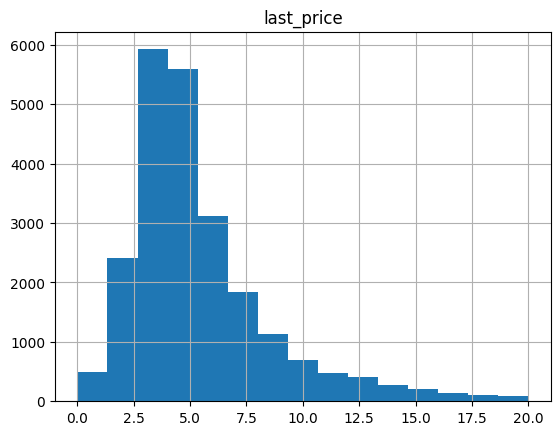

In [68]:
(df['last_price'] / 1000000).hist(bins=15, range=(0,20))
plt.title('last_price')

Вывод: 
* Больше всего объявлений на рынке стоимостью от 2млн до 5млн.
* Медианное значение - 4 650 000.0
* Среднее значени - 6 541 126.89

#### количество комнат

In [69]:
df['rooms'].median()

np.float64(2.0)

In [70]:
df['rooms'].mean()

np.float64(2.002270742358079)

Text(0.5, 1.0, 'rooms')

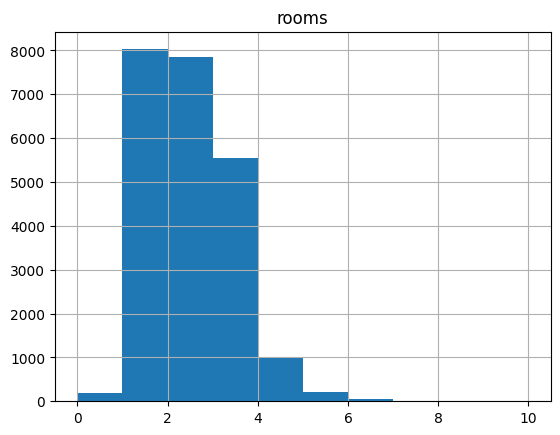

In [71]:
df['rooms'].hist(bins=10, range=(0, 10))
plt.title('rooms')

Вывод: 
* Больше всего объявлений на рынке с количеством комнат от 1 до 3
* Среднее значени - 2.0
* Медианное значение - 2.0

#### высота потолков

In [72]:
df['ceiling_height'].median()

np.float64(2.65)

In [73]:
df['ceiling_height'].mean()

np.float64(2.6887301310043665)

In [74]:
df[(df['ceiling_height'] > 11) & (df['ceiling_height'] < 20)]['ceiling_height']

15061    14.0
Name: ceiling_height, dtype: float64

Text(0.5, 1.0, 'ceiling_height')

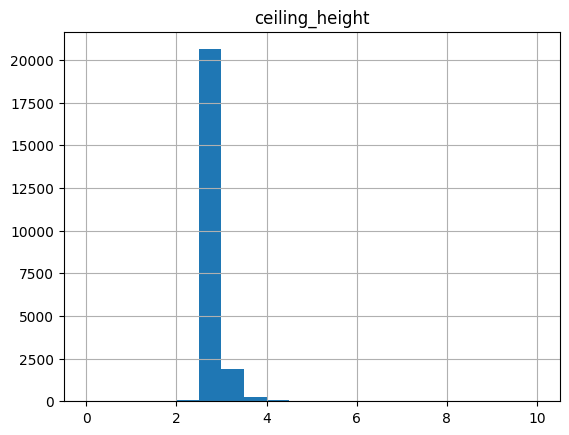

In [75]:
df['ceiling_height'].hist(bins=20, range=(0, 10))
plt.title('ceiling_height')

Вывод: 
* Больше всего объявлений на рынке с высотой потолков от 2.5 до 3.0 м.
* Медианное значение - 2.65
* Среднее значение - 2.70

#### этаж квартиры

In [76]:
df['floor'].median()

np.float64(4.0)

In [77]:
df['floor'].mean()

np.float64(5.899039301310044)

Text(0.5, 1.0, 'floor')

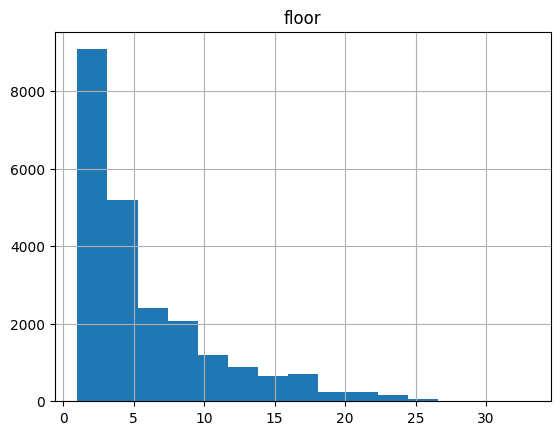

In [78]:
df['floor'].hist(bins=15)
plt.title('floor')

Вывод: 
* Больше всего объявлений на рынке имеют этажность от 1-го до 5-го этажа
* Медианное значение - 4
* Среднее значение - 6

#### тип этажа квартиры

In [79]:
df['floor_type'].value_counts(normalize=True)

floor_type
другой       0.732576
последний    0.142096
первый       0.125328
Name: proportion, dtype: float64

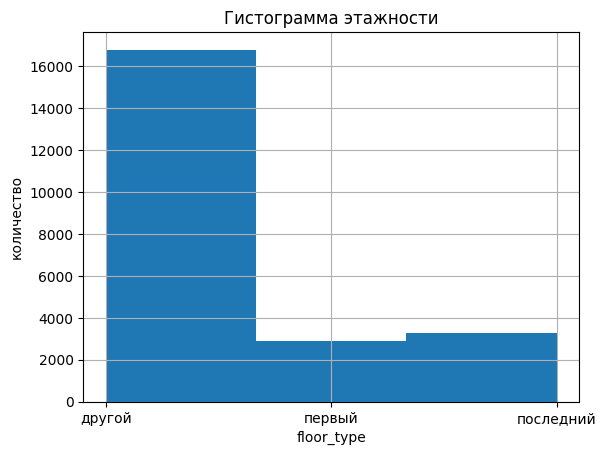

In [80]:
# df['floor_type'].hist(bins=3)
fig, ax = plt.subplots()
ax.hist(df['floor_type'], bins=3)
ax.set_xlabel('floor_type')
ax.set_ylabel('количество')
ax.set_title('Гистограмма этажности')
ax.grid()

Вывод: 
* Доля квартир на первом и последнем этажах составляет 0.142 и 0.125


#### общее количество этажей в доме

In [81]:
df['floors_total'].median()

np.float64(9.0)

In [82]:
df['floors_total'].mean()

np.float64(10.744323144104804)

Text(0.5, 1.0, 'floors_total')

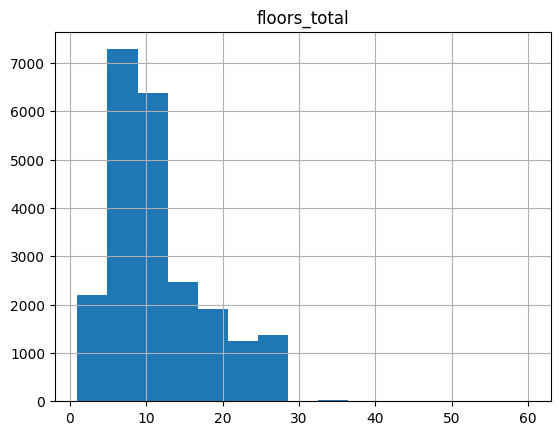

In [83]:
df['floors_total'].hist(bins=15)
plt.title('floors_total')

Вывод: 
* Больше всего домов на рынке этажностью от 5 до 12 этажей.
* Медианное значение - 9
* Среднее значение - 11

#### расстояние до центра города в метрах

In [84]:
df['cityCenters_nearest'].median()

np.float64(11.0)

In [85]:
df['cityCenters_nearest'].mean()

np.float64(10.65467248908297)

Text(0.5, 1.0, 'cityCenters_nearest')

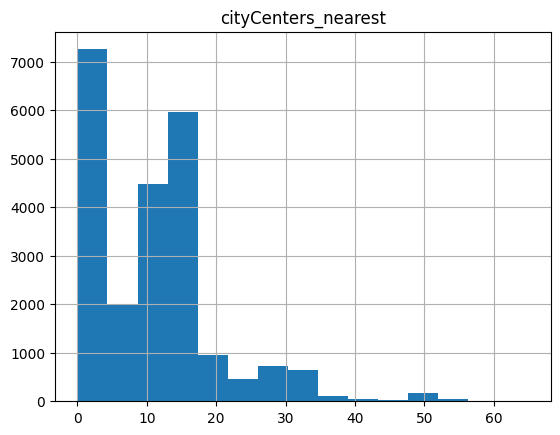

In [86]:
df['cityCenters_nearest'].hist(bins=15)
plt.title('cityCenters_nearest')

Вывод: 
* На графике видно много выбросов с расстоянием до центра 0, для многих объявлений этой информации нет.
* Больше всего объявлений на рынке на окраине города с расстоянием до центра от 10км до 17,5км (новостройки за КАДом)
* Медианное значение - 11 250.0
* Среднее значение - 10 889.42

#### расстояние до ближайшего аэропорта

In [87]:
df[df['airports_nearest'] > 0]['airports_nearest'].median()

np.float64(26886.0)

In [88]:
df[df['airports_nearest'] > 0]['airports_nearest'].mean()

np.float64(28867.011156478235)

Text(0.5, 1.0, 'airports_nearest')

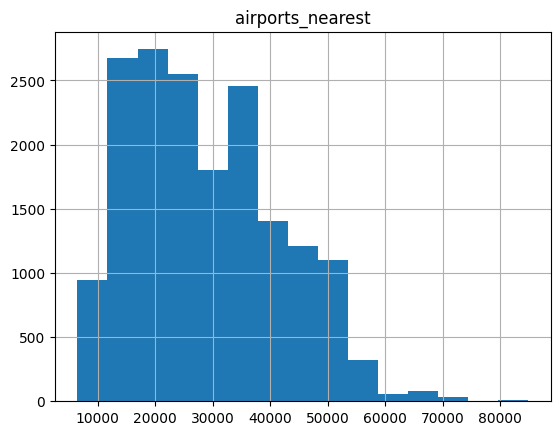

In [89]:
df[df['airports_nearest'] > 0]['airports_nearest'].hist(bins=15)
plt.title('airports_nearest')

Вывод: 
* Убрал выбросы с нулевыми значениями
* Больше всего объявлений на рынке от 12 км до 27км от аэропорта. 
* Медианное значение - 26 757.0
* Среднее значение - 28 804.81

#### расстояние до ближайшего парка

In [90]:
df[df['parks_nearest'] > 0]['parks_nearest'].median()

np.float64(456.0)

In [91]:
df[df['parks_nearest'] > 0]['parks_nearest'].mean()

np.float64(493.78904073238687)

Text(0.5, 1.0, 'parks_nearest')

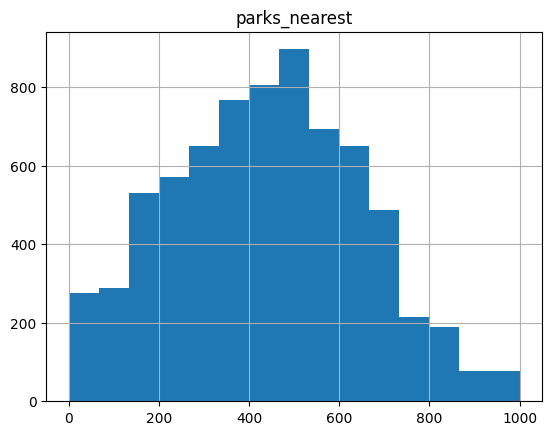

In [92]:
df[df['parks_nearest'] > 0]['parks_nearest'].hist(bins=15, range=(0, 1000))
plt.title('parks_nearest')

Вывод: 
* Убрал выбросы с нулевыми значениями
* Медианное значение - 454.5
* Среднее значение - 490.83

#### день и месяц публикации объявления

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'понедельник'),
  Text(1, 0, 'пятница'),
  Text(2, 0, 'воскресение'),
  Text(3, 0, 'суббота'),
  Text(4, 0, 'четверг'),
  Text(5, 0, 'среда'),
  Text(6, 0, 'вторник')])

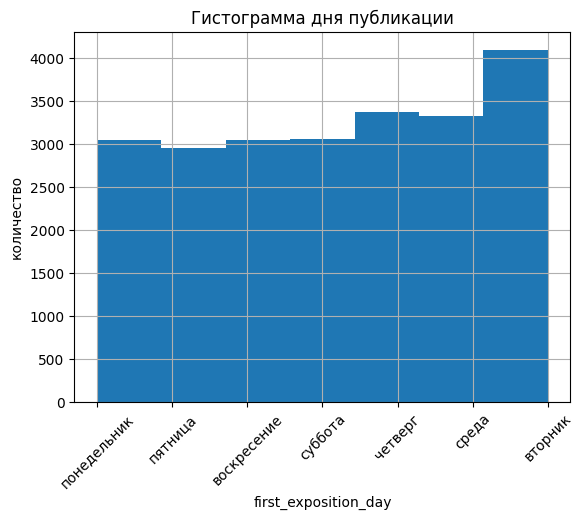

In [93]:
# df['first_exposition_day'].hist(bins=7, xrot=45)
fig, ax = plt.subplots()
ax.hist(df['first_exposition_day'], bins=7)
ax.set_xlabel('first_exposition_day')
ax.set_ylabel('количество')
ax.set_title('Гистограмма дня публикации')
ax.grid()
plt.xticks(rotation = 45)

Text(0.5, 1.0, 'first_exposition_month')

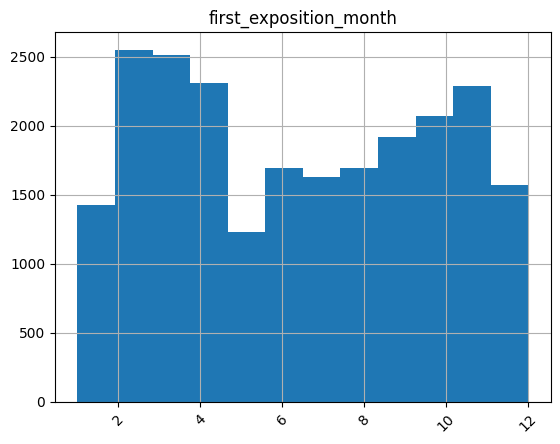

In [94]:
df['first_exposition_month'].hist(bins=12, xrot=45)
plt.title('first_exposition_month')

Вывод: 
* Есть небольшой всплеск активности продавцов по вторникам.
* Обычно продавцы квартир активизируются в конце зимы, в начале весны и в конце осени.
* Меньше всего объявлений размещается с мая по август, а также в декабре-январе

### Задания на исследлвания

#### Изучите, как быстро продавались квартиры

In [95]:
df['days_exposition'].median()

np.float64(93.0)

In [96]:
df['days_exposition'].mean()

np.float64(177.53545796737765)

Text(0.5, 1.0, 'days_exposition')

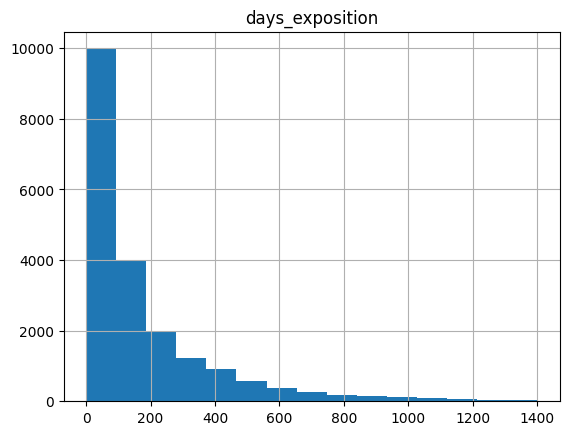

In [97]:
df['days_exposition'].hist(bins=15, range=(0, 1400))
plt.title('days_exposition')

<Axes: >

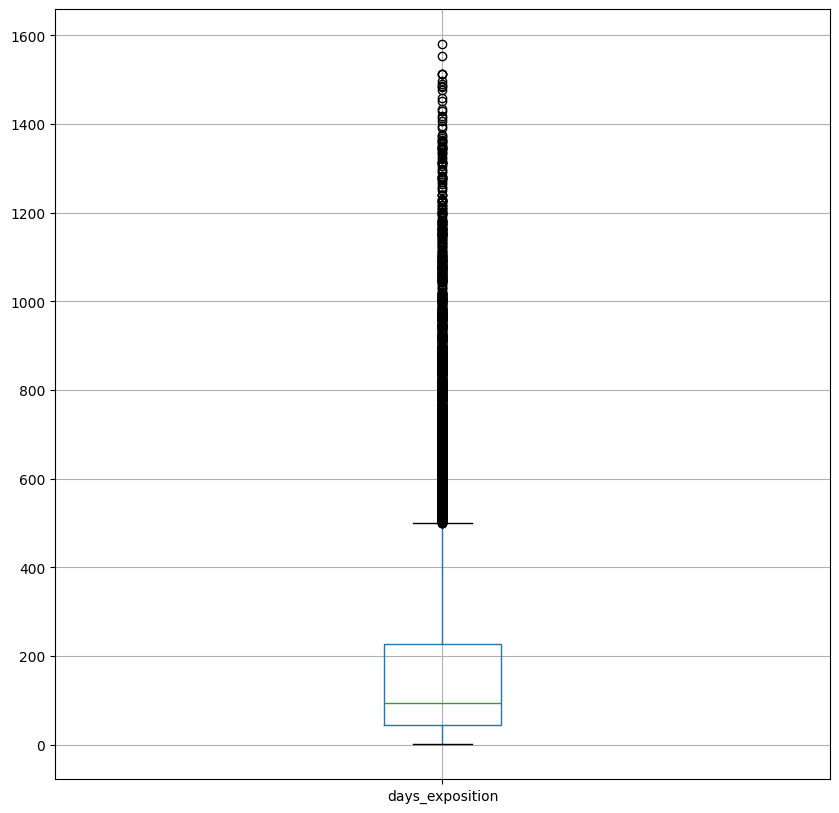

In [98]:
df.boxplot(column='days_exposition', figsize=(10,10))

Выводы:
* Не учтены квартиры, которые еще не проданы.
* Половина квартир продается за первые три месяца с момента размещения.
* Из-за отдельных экземпляров среднее значение смещается к 180 дням. 
* К быстрым продажам можно отнести первый квартиль, когда квартира продается быстрее, чем 50 дней.
* К долгим продажам можно отнести четвертый квартиль, когда квартира продается от 250 до 500 дней

Text(0.5, 1.0, 'days_exposition')

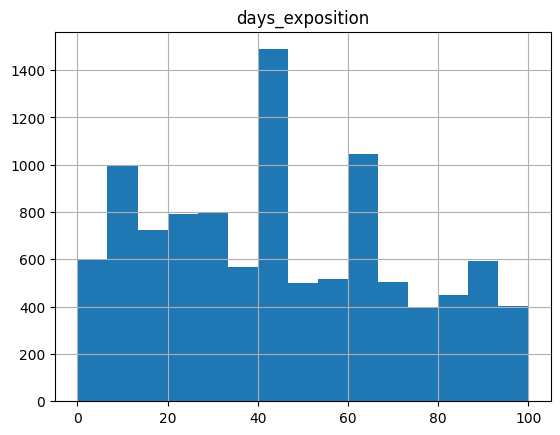

In [99]:
df['days_exposition'].hist(bins=15, range=(0, 100))
plt.title('days_exposition')

#### Какие факторы больше всего влияют на общую (полную) стоимость объекта

##### общая площадь

<Axes: xlabel='total_area', ylabel='last_price'>

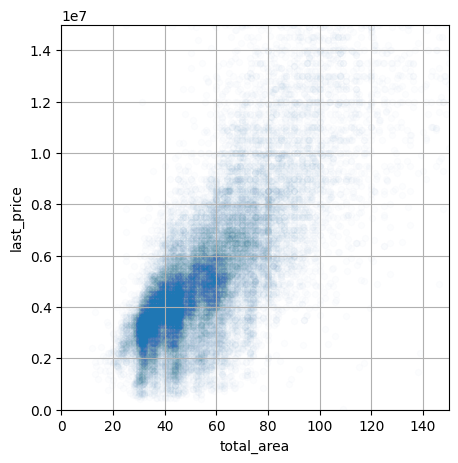

In [100]:
df.plot(x='total_area',
        y='last_price',
        kind='scatter',
        xlim=(0, 150),
        ylim=(0, 15000000),
        figsize=(5,5),
        grid=True,
        alpha = 0.01
       )

Выводы:
* Видна линейная зависимость, между стоимостью квартиры и ее площадью

##### Жилая площаль

<Axes: xlabel='living_area', ylabel='last_price'>

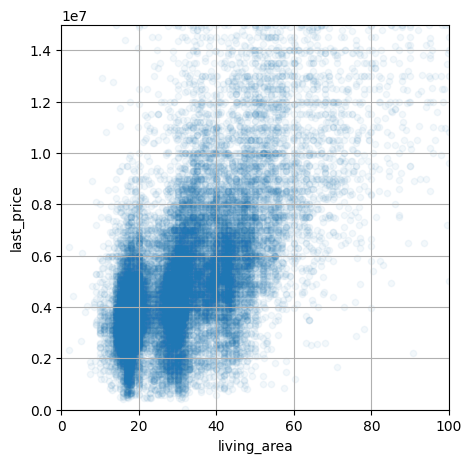

In [101]:
df.plot(x='living_area',
        y='last_price',
        kind='scatter',
        xlim=(0, 100),
        ylim=(0, 15000000),
        figsize=(5,5),
        grid=True,
        alpha = 0.05
       )

Выводы:
* Видна линейная зависимость, между стоимостью квартиры и ее жилой площадью.
* Есть интересные три вертикальные области, скорее всего они соответствуют жилой площадь для одно, двух и трехкомнатных квартир.
* При одинаковой жилой площади стоимость изменяется от 2млн до 8млн.
* В этих областях видно, что кроме жилой площади на стоимость жилья влияет много других факторов.

##### Площади кухни

<Axes: xlabel='kitchen_area', ylabel='last_price'>

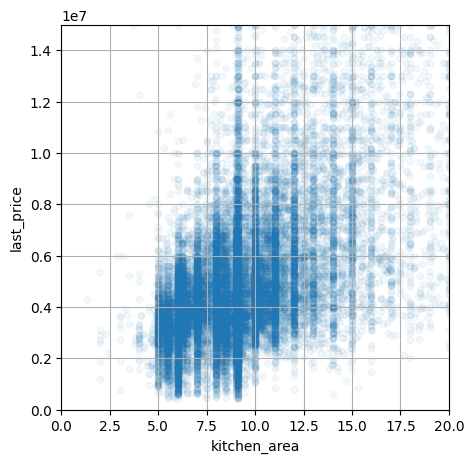

In [102]:
df.plot(x='kitchen_area',
        y='last_price',
        kind='scatter',
        xlim=(0, 20),
        ylim=(0, 15000000),
        figsize=(5,5),
        grid=True,
        alpha = 0.05
       )

Выводы:
* Зависимоть между площадью кухни и ценой квартиры не ярко выражена.
* Площадь кухни слабо влияет на стоимость квартиры, т.к. в большинстве объявлений они изменяется в малом диапазоне
* Есть также вертикальные штрихи на графике, где более ярко, чем в жилой площади, видно, что площадь кухни не решающий фактор для определения стоимости квартиры.

##### Количество комнат

<Axes: xlabel='rooms', ylabel='last_price'>

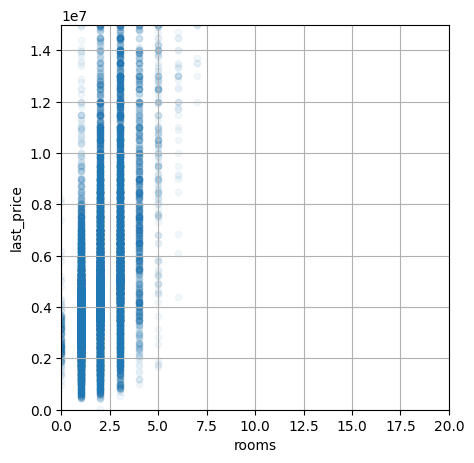

In [103]:
df.plot(x='rooms',
        y='last_price',
        kind='scatter',
        xlim=(0, 20),
        ylim=(0, 15000000),
        figsize=(5,5),
        grid=True,
        alpha = 0.05
       )

Такой график не дает четкого ответа на вопрос

In [104]:
df.groupby('rooms')['last_price'].agg(['count', 'median'])

,count,median
rooms,,
0,196,2700000.0
1,8025,3600000.0
2,7849,4750000.0
3,5552,6000000.0
4,995,8100000.0
5,218,10995000.0
6,52,13015000.0
7,13,15000000.0


Для анализа зависимости стоимости квартиры от количества комнат, оставляем объявления с количеством комнат меньше шести и строим график по медианным значениям. На такой тип квартир приходится основная часть объявлений.

<Axes: xlabel='rooms'>

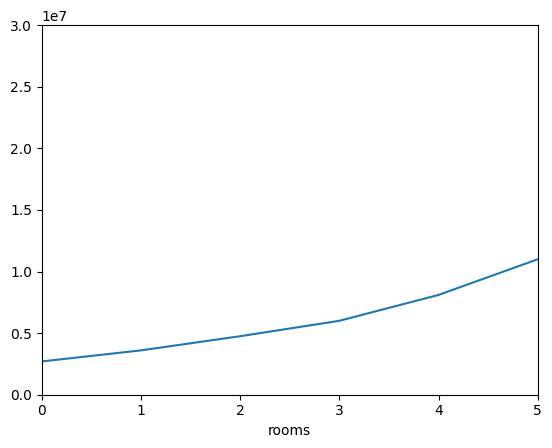

In [105]:
df.groupby('rooms')['last_price'].median().plot(xlim=(0,5), ylim=(0, 30000000))

Выводы:
* Зависимоть между количеством комнат и ценой квартиры отчетливо видна на графике.

##### Типа этажа, на котором расположена квартира

In [106]:
df.groupby('floor_type')['last_price'].median()

floor_type
другой       4750000.0
первый       3894500.0
последний    4200000.0
Name: last_price, dtype: float64

<Axes: xlabel='floor_type'>

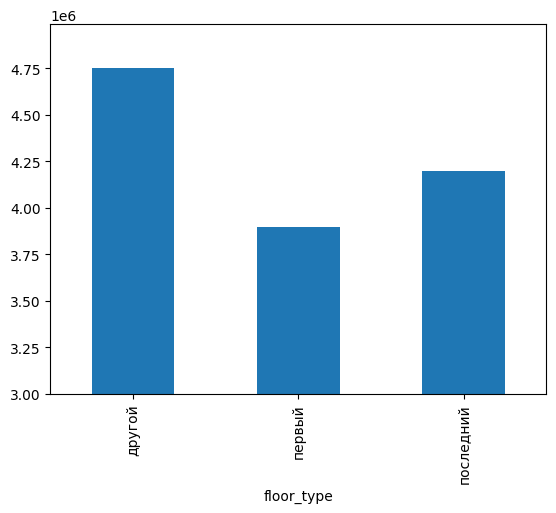

In [107]:
df.groupby('floor_type')['last_price'].median().plot(kind='bar', ylim=3000000)

Выводы:
* Люди не хотят жить на первом этаже, спрос на такие квартиры ниже, поэтому продавцам приходится снижать цену.
* Последний этаж пользуется большей популярностью, чем первый. 
* В основном люди предпочитаю жить не на последнем и не на первом этажах, что демонстрирует большая медианна стоимость таких квартир.

##### Даты размещения (день недели, месяц, год)

<Axes: xlabel='first_exposition_day'>

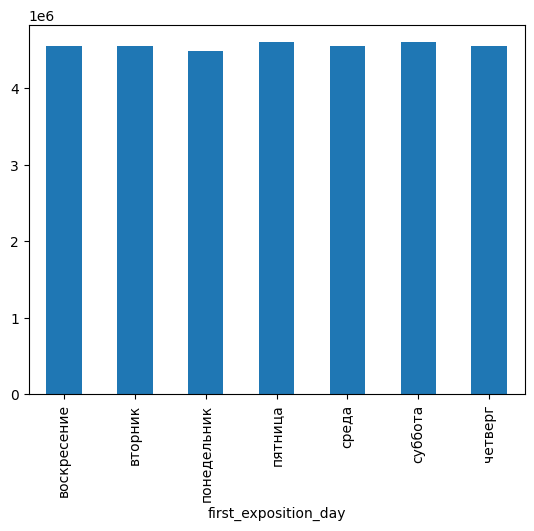

In [108]:
df.groupby('first_exposition_day')['last_price'].median().plot(kind='bar')

<Axes: xlabel='first_exposition_month'>

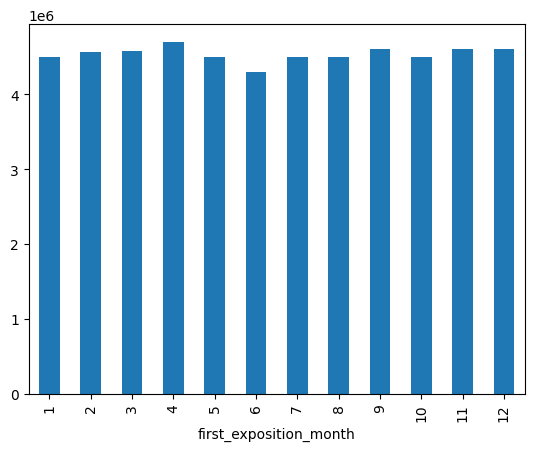

In [109]:
df.groupby('first_exposition_month')['last_price'].median().plot(kind='bar')

<Axes: xlabel='first_exposition_year'>

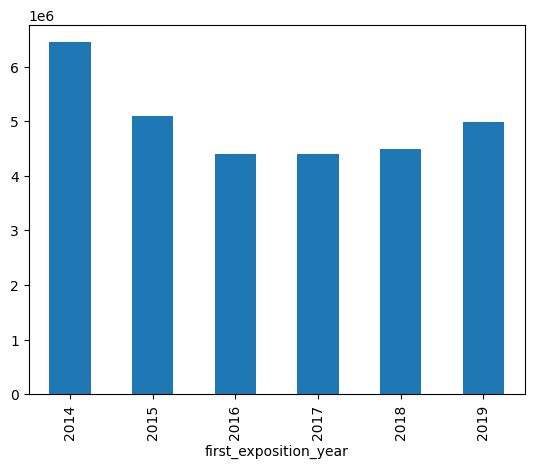

In [110]:
df.groupby('first_exposition_year')['last_price'].median().plot(kind='bar')

Выводы:
* Графики с размещением объявлений по дням и месяцам никакой интересной зависимости не демонстрируют.
* График с размещением объявлений по годам показывает динамику медианной цены на квартиры от года к году.

#### Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений

In [111]:
top_10 = df.groupby('locality_name')['locality_name'].count().sort_values(ascending=False)[:10]

In [112]:
top_10

locality_name
санкт-петербург      14997
поселок мурино         556
поселок шушары         440
всеволожск             397
пушкин                 359
колпино                337
поселок парголово      326
гатчина                307
деревня кудрово        299
выборг                 237
Name: locality_name, dtype: int64

In [113]:
df.query('locality_name in @top_10.index').groupby('locality_name')['sqmeter_price'].mean().sort_values(ascending=False)

locality_name
санкт-петербург      108764.876263
пушкин               101867.482517
деревня кудрово       92473.547576
поселок парголово     90332.263023
поселок мурино        85681.762601
поселок шушары        78677.364217
колпино               75333.295801
гатчина               68746.146763
всеволожск            67214.252635
выборг                58141.909153
Name: sqmeter_price, dtype: float64

<Axes: xlabel='locality_name'>

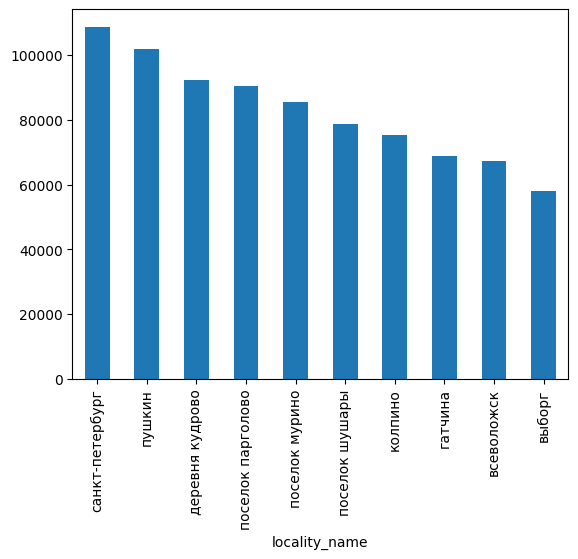

In [114]:
(df.query('locality_name in @top_10.index')
 .groupby('locality_name')['sqmeter_price']
 .mean()
 .sort_values(ascending=False)
 .plot(kind='bar')
)

Выводы:
* В среднем самыя высока цена квадратного метра в Санкт-Петербурге и Пушкине.
* На втором месте можно выделить Кудрово, Парголово, Мурино
* Замыкает список самых дорогих квартир - Выборг.

#### Вычислите среднюю цену каждого километра удаленности от центра в Санкт-Петерурге

Средняя цена километра удаленности от центра в Санкт-Петербурге

In [115]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,sqmeter_price,first_exposition_day,first_exposition_month,first_exposition_year,floor_type
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,False,False,False,25.0,0.0,санкт-петербург,18863.0,16,1.0,482.0,2.0,755.0,NaN,120370.370370,понедельник,3,2019,другой
1,7,3350000.0,40.4,2018-12-04,1,2.65,11.0,18.6,1,False,False,False,11.0,2.0,поселок шушары,12817.0,18,0.0,0.0,0.0,0.0,81.0,82920.792079,пятница,12,2018,первый
2,10,5196000.0,56.0,2015-08-20,2,2.65,5.0,34.3,4,False,False,False,8.3,0.0,санкт-петербург,21741.0,13,1.0,90.0,2.0,574.0,558.0,92785.714286,воскресение,8,2015,другой
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,False,False,False,41.0,0.0,санкт-петербург,31856.0,8,2.0,112.0,1.0,48.0,121.0,100000.000000,суббота,6,2018,другой
5,10,2890000.0,30.4,2018-09-10,1,2.65,12.0,14.4,5,False,False,False,9.1,0.0,городской поселок янино-1,0.0,0,0.0,0.0,0.0,0.0,55.0,95065.789474,четверг,9,2018,другой


<Axes: xlabel='cityCenters_nearest'>

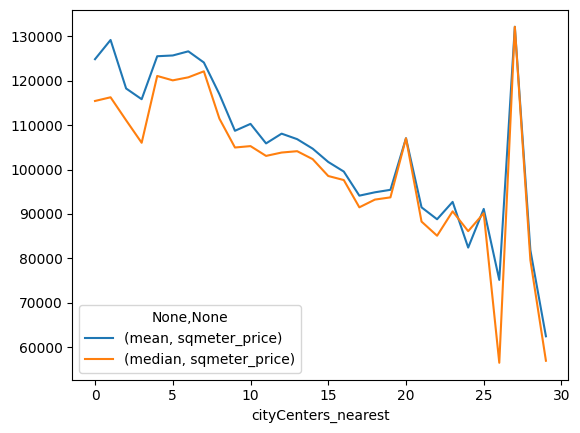

In [116]:
(df[df['locality_name'] == 'санкт-петербург']
 .pivot_table(
    index='cityCenters_nearest',
    values='sqmeter_price',
    aggfunc=['mean','median'])
 .plot()
)

Выводы:
* Отчетливо видко, что с удалением от центра города цена падает с отдельным пиком - есть области с ценой квадратного метра на уровне города, но на достаточном удалении. Похоже построили элитного жилья на окраине.

### Общий вывод

Общие выводы по исследованию датасета:
* Квартиры продаются довольно быстро, половина продается за первые три месяца.
* Стоимость квартиры больше всего зависит от ее площади и, как следствие, от количества комнат.
* Стоимость квартир на первом и последнем этаже в среднем ниже стоимости на всех остальных этажах.
* Площадь кухни практически не влияет на стоимость квартиры, т.к. в самых многочисленных объявлениях площадь кухни не сильно отличается от среднего значения.
* Наблюдается закономерность в сезонности разещения объявлений: 
    * Обычно продавцы квартир активизируются в конце зимы, в начале весны и в конце осени.
    * Меньше всего объявлений размещается с мая по август, а также в декабре-январе
* Больше всего объявлений в Санкт-Петербурге
* Самые дорогие квартиры в Санкт-Петербурге и Пушкине
* С удалением от центра города стоимость квадратного метра падает, но наблюдаются несколько пиков, где построено дорогостоящее жилье на отдалении от центра.
